# 5 在无标记数据集上进行预训练

![alt text](../../data/预训练/img/37610407975c2975f4a5dc37831d3f97.png)

## 5.1 生成式文本模型的评估

In [2]:
# 使用GPT生成文本

import torch
from architectures import GPTModel
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,        #A
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,             #B
    "qkv_bias": False
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

#A 我们将上下文长度从1024个token缩短到256个token
#B 将 dropout 设置为 0 是一种常见的做法


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [8]:
# Listing 5.1 Utility functions for text to token ID conversion
import tiktoken
# Listing 4.8 A function for the GPT model to generate text
def generate_text_simple(model, idx, max_new_tokens, context_size):  # A
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]  # B
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]  # C
        probas = torch.softmax(logits, dim=-1)  # D
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # E
        idx = torch.cat((idx, idx_next), dim=1)  # F

    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


## 5.1.2/3 文本生成损失的计算

In [9]:
file_path = "/Users/wangyc/Desktop/projects/build_large_language_model/data/预训练/the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()


In [10]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)


Characters: 20482
Tokens: 5147


In [11]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


In [13]:
from torch.utils.data import Dataset, DataLoader
import tiktoken


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)  # A

        for i in range(0, len(token_ids) - max_length, stride):  # B
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):  # C
        return len(self.input_ids)

    def __getitem__(self, idx):  # D
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(
    txt,
    batch_size=4,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
    num_workers=0,
):
    tokenizer = tiktoken.get_encoding("gpt2")  # A
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)  # B
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,  # C
        num_workers=0,  # D
    )

    return dataloader

In [14]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)


In [15]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)


Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


可以看到，训练集中共有 9 个批次，每批包含 2 个样本，每个样本有 256 个 token。由于只分配了 10% 的数据用于验证，因此验证集中只有 1 个批次，包含 2 个样本。

和我们的预期一致，输入数据（x）和目标数据（y）的形状相同（即批次大小 × 每批的 token 数量），因为目标数据是将输入数据整体向后偏移一个位置得到的，正如第 2 章讨论的那样。

接下来我们实现一个工具函数，用于计算由训练和验证加载器返回的批量数据的交叉熵损失：

In [16]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)       #A
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

#A 将数据传输到指定设备（如 GPU），使数据能够在 GPU 上处理。


In [17]:
# Listing 5.2 Function to compute the training and validation loss
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)                                    #A
    else:
        num_batches = min(num_batches, len(data_loader))                  #B
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()                                     #C
        else:
            break
    return total_loss / num_batches                                       #D


#A 如果没有指定批次数，将自动遍历所有批次
#B 若批次数超过数据加载器的总批次数，则减少批次数使其与数据加载器的批次数相匹配
#C 每个批次的损失求和
#D 对所有批次的损失取平均值


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #A
model.to(device)
with torch.no_grad():                                                 #B
    train_loss = calc_loss_loader(train_loader, model, device)        #C
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)


#A 如果你的设备配备了支持 CUDA 的 GPU，LLM 将自动在 GPU 上进行训练，无需更改代码
#B 因为当前不在训练，为提高效率，关闭梯度跟踪
#C 通过 device 设置确保数据与 LLM 模型加载到同一设备上


Training loss: 10.987583690219456
Validation loss: 11.021605491638184


## 5.2 训练LLM

In [21]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()                #A
    with torch.no_grad():       #B
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

#A 评估阶段禁用 dropout，以确保结果稳定、可复现
#B 禁用梯度跟踪，减少计算开销


In [22]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
        decoded_text = token_ids_to_text(token_ids, tokenizer)
        print(decoded_text.replace("\n", " ")) # Compact print format
    model.train()


In [23]:
# Listing 5.3 The main function for pretraining LLMs
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []                        #A
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):                                                 #B
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()                                                   #C
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()                                                         #D
            optimizer.step()                                                        #E
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:                                        #F
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        generate_and_print_sample(                                                  #G
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen


#A 初始化用于记录损失和已处理 token 数量的列表
#B 开始主训练循环
#C 重置上一批次的损失梯度
#D 计算损失梯度
#E 使用损失梯度更新模型权重
#F 可选的评估步骤
#G 每个 epoch 结束后打印示例文本


In [24]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)      #A
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=1,
    start_context="Every effort moves you", tokenizer=tokenizer
)

#A .parameters() 方法返回模型的所有可训练权重参数


Ep 1 (Step 000000): Train loss 9.897, Val loss 9.951
Ep 1 (Step 000005): Train loss 7.917, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.847, Val loss 7.044
Ep 2 (Step 000015): Train loss 5.997, Val loss 6.604
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.659, Val loss 6.617
Ep 3 (Step 000025): Train loss 5.363, Val loss 6.330
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.010, Val loss 6.281
Ep 4 (Step 000035): Train loss 2.549, Val loss 6.227
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.834, Val loss 6.149
Every effort moves you know it was not that the picture--I had the fact by the last

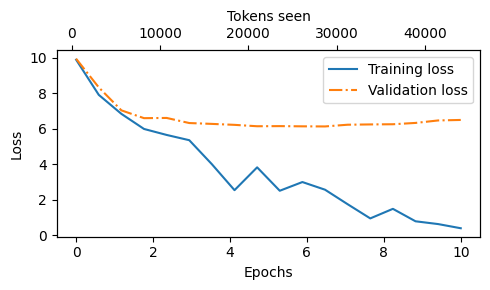

In [25]:
import matplotlib.pyplot as plt
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2 = ax1.twiny() #A
    ax2.plot(tokens_seen, train_losses, alpha=0) #B
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

#A 创建与 y 轴共用的第二个 x 轴
#B 用于对齐刻度的隐藏图形


如图 5.12 所示，训练损失和验证损失在第一个 epoch 开始时都有所改善。然而，从第二个 epoch 之后，损失开始出现分歧。验证损失远高于训练损失，这表明模型在训练数据上出现了过拟合。我们可以通过搜索生成的文本片段（例如“The Verdict”文件中的片段：“quite insensible to the irony”）来确认模型逐词记住了训练数据。

这种记忆现象是预料之中的，因为我们使用了一个非常小的训练数据集，并且对模型进行了多轮训练。通常，我们会在更大的数据集上训练模型，并且只需训练一个 epoch 即可。

- 预训练到此为止，拿到模型权重， 输出logits，即是预训练干的事。后面是推理的策略了

## 5.3 通过解码策略控制生成结果的随机性

首先，我们将模型从 GPU 转移回 CPU，因为相对较小的模型在推理时不需要使用 GPU。另外，在训练结束后，我们会将模型切换到评估模式，以关闭 dropout 等随机组件：接下来，将 GPTModel 的实例（model）传入 generate_text_simple 函数，该函数使用 LLM 一次生成一个 token：

In [27]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




### 5.3.1 温度

In [28]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}


In [29]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)


In [30]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])


forward


In [31]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])


forward


In [32]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)


73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


从输出结果可以看出，单词‘forward’在生成过程中被采样的次数最多（在 1000 次生成中出现了 582 次），但‘closer’、‘inches’和‘toward’等其他词语也偶尔会被采样到。这意味着，如果在生成函数 generate_and_print_sample 中将 argmax 替换为 multinomial，模型有时会生成类似‘every effort moves you toward’、‘every effort moves you inches’和‘every effort moves you closer’这样的句子，而不是固定生成‘every effort moves you forward’。

我们可以通过一种称为temperature scaling的方法进一步控制分布和选择过程，所谓temperature scaling，其实就是将 logits 除以一个大于 0 的数

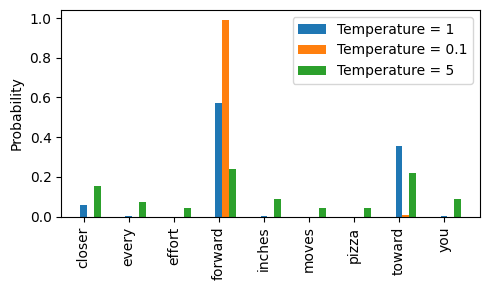

In [33]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)
#Temperatures greater than 1 result in more uniformly distributed token probabilities, and Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions. Let's illustrate this by plotting the original probabilities alongside probabilities scaled with different temperature values:
temperatures = [1, 0.1, 5]             #A
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

#A 原始、较低和较高置信度


当 temperature 取 1 时，logits 在传递给 softmax 函数之前会除以 1，计算概率得分。这意味着，temperature 为 1 时相当于不进行任何缩放。在这种情况下，模型将根据原始的 softmax 概率，通过 PyTorch 中的multinomial函数来选择 token。

如图 5.14 所示，当 temperature 设置为非常小的值（如 0.1）时，生成的分布会更加尖锐，因此multinomial函数几乎总是选择最可能的 token（这里是 ‘forward’），其行为接近 argmax 函数。相反，当 temperature 设置为 5 时，生成的分布更接近均匀分布，其他 token 被选中的频率更高。这种情况下，生成的文本多样性增加，但也更可能出现无意义的内容。例如，temperature 设置为 5 时，模型生成类似 ‘every effort moves you pizza’ 的文本概率大约为 4%。

### 5.3.2 TOP-K

在前一节中，我们实现了一种结合temperature scaling的概率采样方法来增加生成内容的多样性。我们发现，较高的 temperature 值会使下一词的概率分布更均匀，从而降低模型反复选择最可能词的概率，这样可以生成更多样化的内容，使生成过程探索那些概率较低但可能更有趣和创意的路径。不过，这种方法的一个缺点是，有时会导致生成语法不正确或完全不合逻辑的内容，比如 "every effort moves you pizza"。

在本节中，我们引入了另一种称为top-k 采样的概念，当与概率采样和temperature scaling结合使用时，可以提升文本生成效果。

在 top-k 采样中，我们可以将采样限制在最有可能的前 k 个 token 内，并通过将其他 token 的概率设为零，将它们排除在选择之外，如图 5.15 所示。

In [34]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)


Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [35]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],   #A
    input=torch.tensor(float('-inf')),              #B
    other=next_token_logits                         #C
)
print(new_logits)

#A 识别出小于 top 3 最小值的 logits
#B 将这些较小的 logits 赋值为负无穷大
#C 保留所有其他 token 的原始 logits


tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [36]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)


tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 整合

前两节介绍了两种增加 LLM 生成文本多样性的概念：temperature scaling和top-k 采样。本节中，我们将这两个概念整合并加入到之前用于生成文本的generate_simple函数中，从而创建一个新的generate函数

# 5.4 保存及加载权重

幸运的是，保存 PyTorch 模型相对简单。推荐的做法是保存模型的 state_dict（状态字典），这是一个字典，用于将模型的每一层映射到其对应的参数上，可以通过 torch.save 函数来实现，代码如下所示：

In [40]:
torch.save(model.state_dict(), "model.pth")


In [41]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))
model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

# 5.5 从OPENAI加载权重

自己去Huggingface上下载大模型权重，以便用于后续微调

# 5.6 本章总结

- 其实token_id就是索引，嵌入的时候是，解码的时候也是

- 大模型的参数量、上下文长度都属于超参数，都是开发者在训练时自行决定的

- 温度设置为0，就是贪婪解码

- 预训练阶段不涉及温度等的解码策略，默认T = 1算交叉熵损失。温度等参数的设置出现在推理阶段

- 结构化输出的约束解码，也是在推理阶段通过修改logits的分布来实现的

- 预训练阶段：模型通过海量文本学习，不断调整权重，最终使得对于任意输入，模型能输出合理的 logits（即每个词作为下一个词的可能性）。训练结束后，这些权重被保存下来。

- 推理阶段：我们加载这些权重，对给定的 prompt 进行前向传播，得到 logits。然后，我们可以对这些 logits 进行各种后处理操作：1、温度缩放（控制分布的尖锐程度）2、top-k / top-p 采样（筛选候选词）3、约束解码（强制符合特定格式）等等。这些操作都是在已有权重生成的 logits 基础上进行的，不改变权重本身